In [1]:
import sys
import pathlib
from pathlib import Path
import os
import os.path as o
import logging
import importlib
import types

import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "simopt" / "__init__.py").exists():
            return candidate
    return start

repo_root = _find_repo_root(Path.cwd())
repo_root_str = str(repo_root)
if repo_root_str in sys.path:
    sys.path.remove(repo_root_str)
sys.path.insert(0, repo_root_str)

In [ ]:
for module_name in list(sys.modules):
    if module_name == "simopt" or module_name.startswith("simopt."):
        del sys.modules[module_name]

mrg32k3a_module = importlib.import_module("mrg32k3a.mrg32k3a")
sys.modules["mrg32k3a.python"] = mrg32k3a_module
sys.modules["mrg32k3a.mrg32k3a"] = mrg32k3a_module

from simopt.experiment_base import ProblemsSolvers, read_experiment_results

# Get the experiments Results directory where all the ProblemsSolvers pickles will be stored
experiment_dir = repo_root.parent / "WSC2026_experiments"
experiment_dir.mkdir(parents=True, exist_ok=True)

local_pathlib_module = types.ModuleType("pathlib._local")
setattr(local_pathlib_module, "PosixPath", pathlib.PosixPath)
setattr(local_pathlib_module, "WindowsPath", pathlib.WindowsPath)
sys.modules["pathlib._local"] = local_pathlib_module

/Users/benjaminrees/miniconda3/envs/simopt/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Experiment 1: Comparison of ADP solver against SGD and DAVN

In this experiment, we open the pickles of the postreps, and run post-normalize, then we get the comparison plot. We also analyse the CSV files to obtain the average across macroreplications:
- the expected percentage of the optimality gap
- The number of iterations 
- The load factor 
- The CPU time in seconds 

In [3]:

path_1 = "/Users/benjaminrees/Desktop/WSC2026_experiments/3_4_25/WSC2026_experiment1/"

#find all the pickles in the directory that contain "POSTREPS" in the filename - get a list of their file paths
pickles = [f for f in os.listdir(path_1) if f.endswith('.pickle') and not "ProblemsSolvers" in f]

print(f"Found {len(pickles)} pickles")
[print(f) for f in pickles]

#now load. the pickle files as ProblemsSolvers objects

ps_list = []
experiments_1 = []
for pkl in pickles:
    #load in experiments but if the solver is RNDSR, skip it
    experiment = read_experiment_results(os.path.join(path_1, pkl))
    # if experiment.solver.name == "RANDOM SEARCH":
    #     print(f"Skipping RNDSR experiment: {pkl}")
    #     continue
    experiments_1.append(experiment) 

print(f"Loaded {len(experiments_1)} experiments")

#print the number of macroreps for each experiment
for exp in experiments_1:
    print(f"Experiment: {exp.solver.name} on {exp.problem.name} has {exp.n_macroreps} macroreps")


Found 18 pickles
ADP_(SGD-IPA)_variant_increased_demand_variance_1.pickle
ADP_ASTROMoRF_variant_default_fixed_factors_1.pickle
ADP_(SGD-IPA)_variant_default_fixed_factors_1.pickle
SGD_(FD)_variant_reduced_capacity_1.pickle
DAVN_variant_increased_demand_variance_1.pickle
SGD_(FD)_variant_increased_demand_variance_1.pickle
DAVN_variant_reduced_capacity_1.pickle
SGD_(IPA)_variant_reduced_capacity_1.pickle
ADP_ASTROMoRF_variant_increased_demand_variance_1.pickle
SGD_(IPA)_variant_increased_demand_variance_1.pickle
SGD_(FD)_variant_default_fixed_factors_1.pickle
ADP_(SGD)_variant_increased_demand_variance_1.pickle
ADP_(SGD-IPA)_variant_reduced_capacity_1.pickle
DAVN_variant_default_fixed_factors_1.pickle
ADP_ASTROMoRF_variant_reduced_capacity_1.pickle
ADP_(SGD)_variant_reduced_capacity_1.pickle
ADP_(SGD)_variant_default_fixed_factors_1.pickle
SGD_(IPA)_variant_default_fixed_factors_1.pickle
Loaded 18 experiments
Experiment: ADP (SGD-IPA) on VANRYZIN-2 has 20 macroreps
Experiment: ADP_ASTROM

In [4]:
#Create an instance of ProblemsSolvers that contains all the experiments

#first need to make experiments a list of list of ProblemSolver objects where each inner list has the same solver 

experiments_sorted = {}
for exp in experiments_1:
    key = exp.solver.name
    if key not in experiments_sorted:
        experiments_sorted[key] = []
    experiments_sorted[key].append(exp)

# pretty print each solver and problem pair in the experiments_sorted
for solver_name, exps in experiments_sorted.items():
    for exp in exps:
        print(f"Solver: {solver_name}, Problem: {exp.problem.name}")
    print("\n")

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list = list(experiments_sorted.values())

#get budget of first experiment and print it
budget = experiments_1[0].problem.factors['budget']
print(f"Budget of first experiment: {budget}")

file_name_path = experiment_dir / "wsc2026_exp_1.pickle"
wsc2026_exp_1 = ProblemsSolvers(experiments=ps_list, file_name_path=file_name_path)

print(f'WSC2026 Experiment 1 ProblemsSolvers has file path: {wsc2026_exp_1.file_name_path}')


Solver: ADP (SGD-IPA), Problem: VANRYZIN-2
Solver: ADP (SGD-IPA), Problem: VANRYZIN-2
Solver: ADP (SGD-IPA), Problem: VANRYZIN-2


Solver: ADP_ASTROMoRF, Problem: VANRYZIN-2
Solver: ADP_ASTROMoRF, Problem: VANRYZIN-2
Solver: ADP_ASTROMoRF, Problem: VANRYZIN-2


Solver: SGD (FD), Problem: VANRYZIN-2
Solver: SGD (FD), Problem: VANRYZIN-2
Solver: SGD (FD), Problem: VANRYZIN-2


Solver: DAVN, Problem: VANRYZIN-2
Solver: DAVN, Problem: VANRYZIN-2
Solver: DAVN, Problem: VANRYZIN-2


Solver: SGD (IPA), Problem: VANRYZIN-2
Solver: SGD (IPA), Problem: VANRYZIN-2
Solver: SGD (IPA), Problem: VANRYZIN-2


Solver: ADP (SGD), Problem: VANRYZIN-2
Solver: ADP (SGD), Problem: VANRYZIN-2
Solver: ADP (SGD), Problem: VANRYZIN-2


Budget of first experiment: 75000
WSC2026 Experiment 1 ProblemsSolvers has file path: /Users/benjaminrees/Desktop/WSC2026_experiments/wsc2026_exp_1.pickle


In [5]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = experiments_1[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
wsc2026_exp_1.post_normalize_policy(n_postreps_init_opt=num_postreps_init_opt)


Logging set to INFO. You will see per-pair progress as they start/finish.
Post-normalizing results.


2026-04-08 21:22:48,203 | INFO | Global policy x* found from SGD (IPA) with objective 166355.3658.


In [ ]:
# Produce basic plots.
import matplotlib.pyplot as plt
from IPython.display import Image, display

from simopt.experiment_base import PlotType, plot_solvability_profiles, plot_budget_history, plot_fn_estimates, plot_progress_curves

PAPER_PLOT_STYLE = {
    "figure.facecolor": "white",
    "figure.figsize": (11.5, 5.4),
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.1,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 13,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,
    "figure.dpi": 180,
    "savefig.dpi": 600,
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "lines.linewidth": 2.8,
    "lines.markersize": 7,
}

plt.rcParams.update(PAPER_PLOT_STYLE)

def _restyle_current_figure(
    *,
    legend_outside: bool = False,
    legend_ncol: int = 1,
    figsize: tuple[float, float] = (11.5, 5.4),
    min_linewidth: float = 2.6,
    ci_linewidth: float = 1.4,
) -> None:
    fig = plt.gcf()
    if not fig.axes:
        return

    if legend_outside and len(fig.axes) > 1:
        legend_outside = False

    fig_width, fig_height = figsize
    if len(fig.axes) >= 3:
        fig_height = min(fig_height, 4.8)
    elif len(fig.axes) == 2:
        fig_height = min(fig_height, 5.0)
    fig.set_size_inches(fig_width, fig_height, forward=True)

    for ax in fig.axes:
        ax.grid(True, alpha=0.25, linestyle="--")
        for spine in ax.spines.values():
            spine.set_linewidth(1.1)

        for line in ax.get_lines():
            alpha = line.get_alpha()
            if alpha is not None and alpha < 0.55:
                line.set_linewidth(max(line.get_linewidth(), ci_linewidth))
            else:
                line.set_linewidth(max(line.get_linewidth(), min_linewidth))

        handles, labels = ax.get_legend_handles_labels()
        if handles and labels:
            existing_legend = ax.get_legend()
            legend_loc = getattr(existing_legend, "_loc", "best") if existing_legend is not None else "best"
            if existing_legend is not None:
                existing_legend.remove()

            unique_pairs = []
            seen_labels: set[str] = set()
            for handle, label in zip(handles, labels):
                if not label or label.startswith("_") or label in seen_labels:
                    continue
                seen_labels.add(label)
                unique_pairs.append((handle, label))

            if unique_pairs:
                uniq_handles, uniq_labels = zip(*unique_pairs)
                if legend_outside:
                    ax.legend(
                        uniq_handles,
                        uniq_labels,
                        loc="center left",
                        bbox_to_anchor=(1.02, 0.5),
                        borderaxespad=0.0,
                        frameon=True,
                        framealpha=0.95,
                        ncol=1,
                    )
                else:
                    ax.legend(
                        uniq_handles,
                        uniq_labels,
                        loc=legend_loc,
                        frameon=True,
                        framealpha=0.95,
                        ncol=max(1, legend_ncol),
                    )

    if legend_outside:
        fig.tight_layout(rect=(0.0, 0.0, 0.80, 1.0))
    else:
        fig.tight_layout()

def _print_path_and_display(
    plot_paths: list[Path],
    *,
    export_pdf: bool = False,
    legend_outside: bool = False,
    legend_ncol: int = 1,
    figsize: tuple[float, float] = (11.5, 5.4),
    min_linewidth: float = 2.6,
    ci_linewidth: float = 1.4,
    dpi: int = 600,
) -> Path:
    if not plot_paths:
        raise ValueError("Expected at least one plot path.")

    _restyle_current_figure(
        legend_outside=legend_outside,
        legend_ncol=legend_ncol,
        figsize=figsize,
        min_linewidth=min_linewidth,
        ci_linewidth=ci_linewidth,
    )

    fig = plt.gcf()
    for plot_path in plot_paths:
        fig.savefig(plot_path, dpi=dpi, bbox_inches="tight")
        print(f"Plot saved to {plot_path!s}")

        if export_pdf and plot_path.suffix.lower() != ".pdf":
            pdf_path = plot_path.with_suffix(".pdf")
            fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
            print(f"PDF copy saved to {pdf_path!s}")

        if plot_path.suffix.lower() in {".png", ".jpg", ".jpeg", ".gif", ".webp"}:
            display(Image(filename=str(plot_path)))

    return plot_paths[-1].parent

In [7]:
# Produce basic plots.

SAVE_PATH: Path | None = None 

print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of comparison_experiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in wsc2026_exp_1.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_same_problem = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_same_problem.append(ps_list)


# wsc2026_exp_1.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(wsc2026_exp_1.experiments)
n_problems = len(wsc2026_exp_1.experiments[0]) if n_solvers > 0 else 0

print(f'number of solvers: {n_solvers}, number of problems: {n_problems}')

Plotting results...
number of solvers: 6, number of problems: 3


In [ ]:
# Remove DAVN from the solvability profile plot since it is not a direct competitor to the other solvers.
experiments_without_davn = [
    solver_experiments
    for solver_experiments in wsc2026_exp_1.experiments
    if solver_experiments and solver_experiments[0].solver.name != "DAVN"
]

SAVE_PATH = _print_path_and_display(
    plot_solvability_profiles(
        experiments=experiments_without_davn,
        plot_type=PlotType.CDF_SOLVABILITY,
        solve_tol=0.3,
        plot_title="Comparison of GP-ADP Reformulation against SGD with Full Horizon",
        legend_loc="upper left",
        plot_conf_ints=True
    ),
    legend_outside=True,
 )

# Group by explicit variant name so default and high-demand-variance are not merged.
from collections import defaultdict
import copy

def _start_solution_signature(experiment) -> tuple[float, ...] | None:
    x0 = getattr(experiment, "x0", None)
    if x0 is None:
        return None
    x0_array = np.asarray(x0, dtype=float).reshape(-1)
    rounded = np.round(x0_array, 12)
    return tuple(float(v) for v in rounded)

def _variant_name(experiment) -> str:
    path_text = str(getattr(experiment, "file_name_path", "")).lower()
    if "reduced_capacity" in path_text:
        return "Reduced Capacity"
    if "increased_demand_variance" in path_text:
        return "High-Demand Variance"
    if "default_fixed_factors" in path_text:
        return "Van Ryzin"
    return "Van Ryzin"

target_solver_names = ["ADP_SGD", "SGD", "SGD with IPA Gradients"]
solver_display_names = {
    "ADP_SGD": "ADP(SGD)",
    "SGD with IPA Gradients": "SGD (Direct Gradients)",
}

experiments_no_davn = [
    exp
    for solver_experiments in wsc2026_exp_1.experiments
    for exp in solver_experiments
    if exp.solver.name != "DAVN"
]

experiments_by_variant = defaultdict(list)
for exp in experiments_no_davn:
    key = (exp.problem.name, _variant_name(exp), _start_solution_signature(exp))
    experiments_by_variant[key].append(exp)

if not experiments_by_variant:
    print("No non-DAVN experiments were found for plotting.")

variant_sort_order = {
    "Van Ryzin": 0,
    "Reduced Capacity": 1,
    "High-Demand Variance": 2,
}

combined_progress_experiments = []
combined_ref_x0 = None
combined_ref_xstar = None

for (problem_name, variant_name, signature), variant_experiments in sorted(
    experiments_by_variant.items(),
    key=lambda item: (
        item[0][0],
        variant_sort_order.get(item[0][1], 99),
        item[0][1],
        item[0][2] or (),
    ),
):
    solver_index = {exp.solver.name: exp for exp in variant_experiments}
    comparison_experiments = [
        solver_index[solver_name]
        for solver_name in target_solver_names
        if solver_name in solver_index
    ]
    comparison_experiments_for_plot = []
    for exp in comparison_experiments:
        exp_for_fn_plot = copy.copy(exp)
        exp_for_fn_plot.solver = copy.copy(exp.solver)
        exp_for_fn_plot.solver.name = solver_display_names.get(exp.solver.name, exp.solver.name)
        comparison_experiments_for_plot.append(exp_for_fn_plot)

    if len(comparison_experiments) < 2:
        available = sorted(solver_index.keys())
        print(
            f"Skipping {variant_name} variant for {problem_name}; "
            f"need both {target_solver_names}, found {available}."
        )
        continue

    print(
        f"Preparing {problem_name} ({variant_name}) for "
        f"{[exp.solver.name for exp in comparison_experiments_for_plot]}"
    )

    for exp in comparison_experiments:
        exp_for_plot = copy.copy(exp)
        exp_for_plot.solver = copy.copy(exp.solver)
        exp_display_name = solver_display_names.get(exp.solver.name, exp.solver.name)
        exp_for_plot.solver.name = f"{exp_display_name} ({variant_name})"

        if combined_ref_x0 is None:
            combined_ref_x0 = np.asarray(exp.x0).reshape(-1).copy()
        if combined_ref_xstar is None:
            combined_ref_xstar = np.asarray(exp.xstar).reshape(-1).copy()

        # Harmonize references on the copied objects only so combined plotting passes
        # the strict common x0/x* checks without mutating original experiment objects.
        exp_for_plot.x0 = tuple(np.asarray(combined_ref_x0).tolist())
        exp_for_plot.xstar = tuple(np.asarray(combined_ref_xstar).tolist())

        combined_progress_experiments.append(exp_for_plot)

    _print_path_and_display(
        plot_fn_estimates(
            experiments=comparison_experiments_for_plot,
            plot_type=PlotType.FN_ESTIMATES_MEAN,
            solver_set_name=f"Function Estimates for {problem_name} ({variant_name})",
            plot_title=f"{problem_name}: GP-ADP Reformulation vs SGD ({variant_name})",
            normalize=True,
            y_normalize=True,
            legend_loc="upper right",
        )
    )

if combined_progress_experiments:
    SAVE_PATH = _print_path_and_display(
        plot_progress_curves(
            experiments=combined_progress_experiments,
            plot_type=PlotType.MEAN,
            plot_title="GP-ADP Reformulation vs SGD Across Problem Variants",
            legend_loc="lower left",
            plot_conf_ints=True,
            allow_xstar_mismatch=True,
        ),
        legend_outside=True,
    )
else:
    print("No valid ADP_SGD/SGD variant pairs were available for the combined progress plot.")

Experiment 1 - variants found: ['High-Demand Variance', 'Default', 'Reduced Capacity']
  High-Demand Variance: ['GP-ADP', 'SGD (FD)', 'SGD (IPA)']
  Default: ['GP-ADP', 'SGD (FD)', 'SGD (IPA)']
  Reduced Capacity: ['GP-ADP', 'SGD (FD)', 'SGD (IPA)']
Plot saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-04-08_21-22-34/plots/SOLVER_SET_optimality_gap_mean_prog_curve.png
PDF copy saved to /Users/benjaminrees/Desktop/simopt/notebooks/experiments/2026-04-08_21-22-34/plots/SOLVER_SET_optimality_gap_mean_prog_curve.pdf


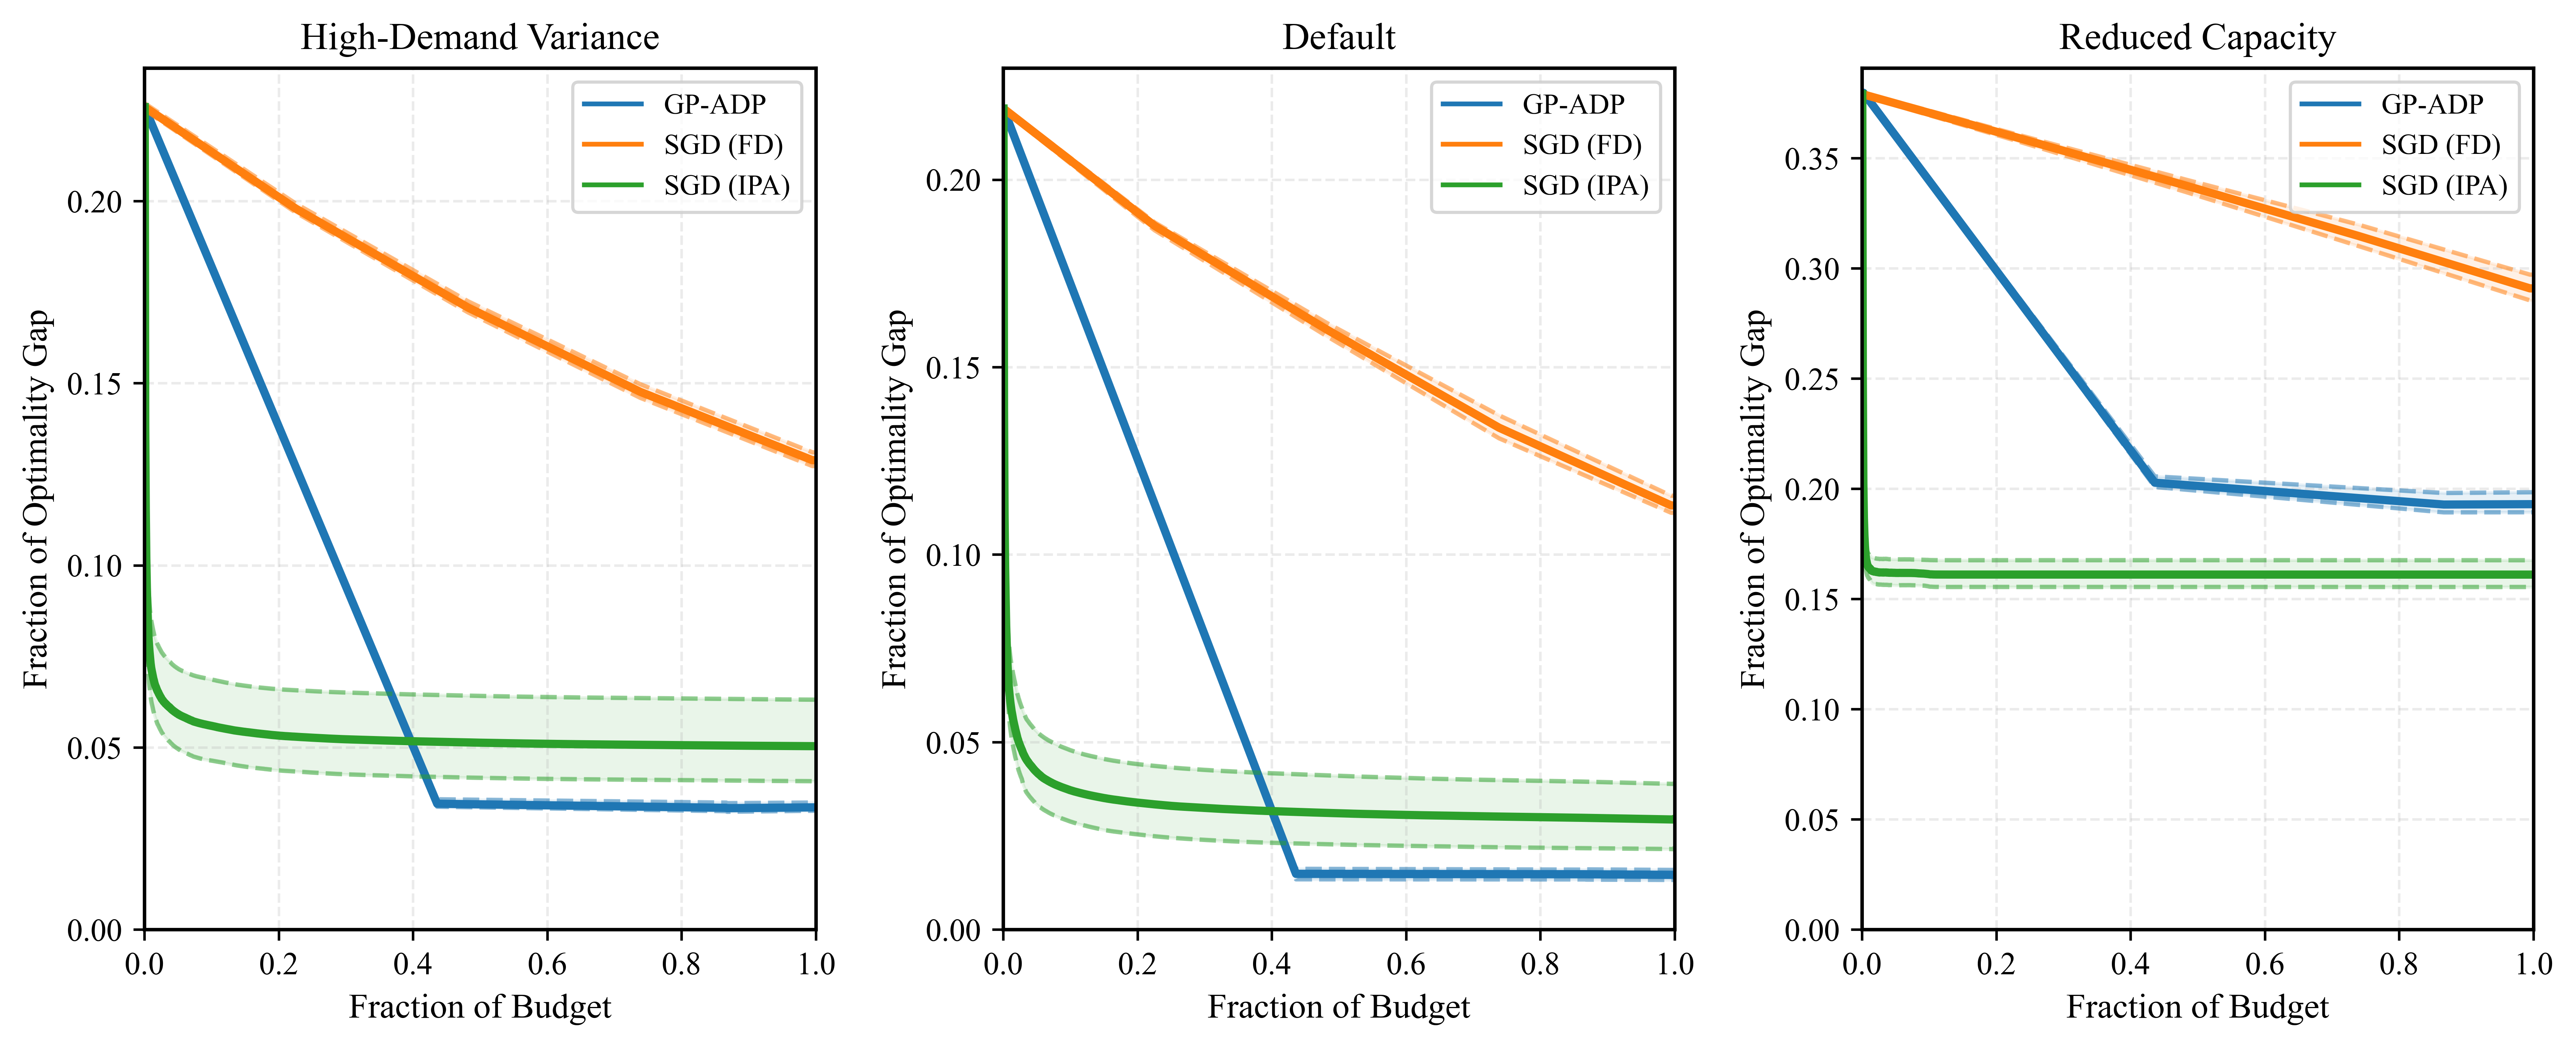

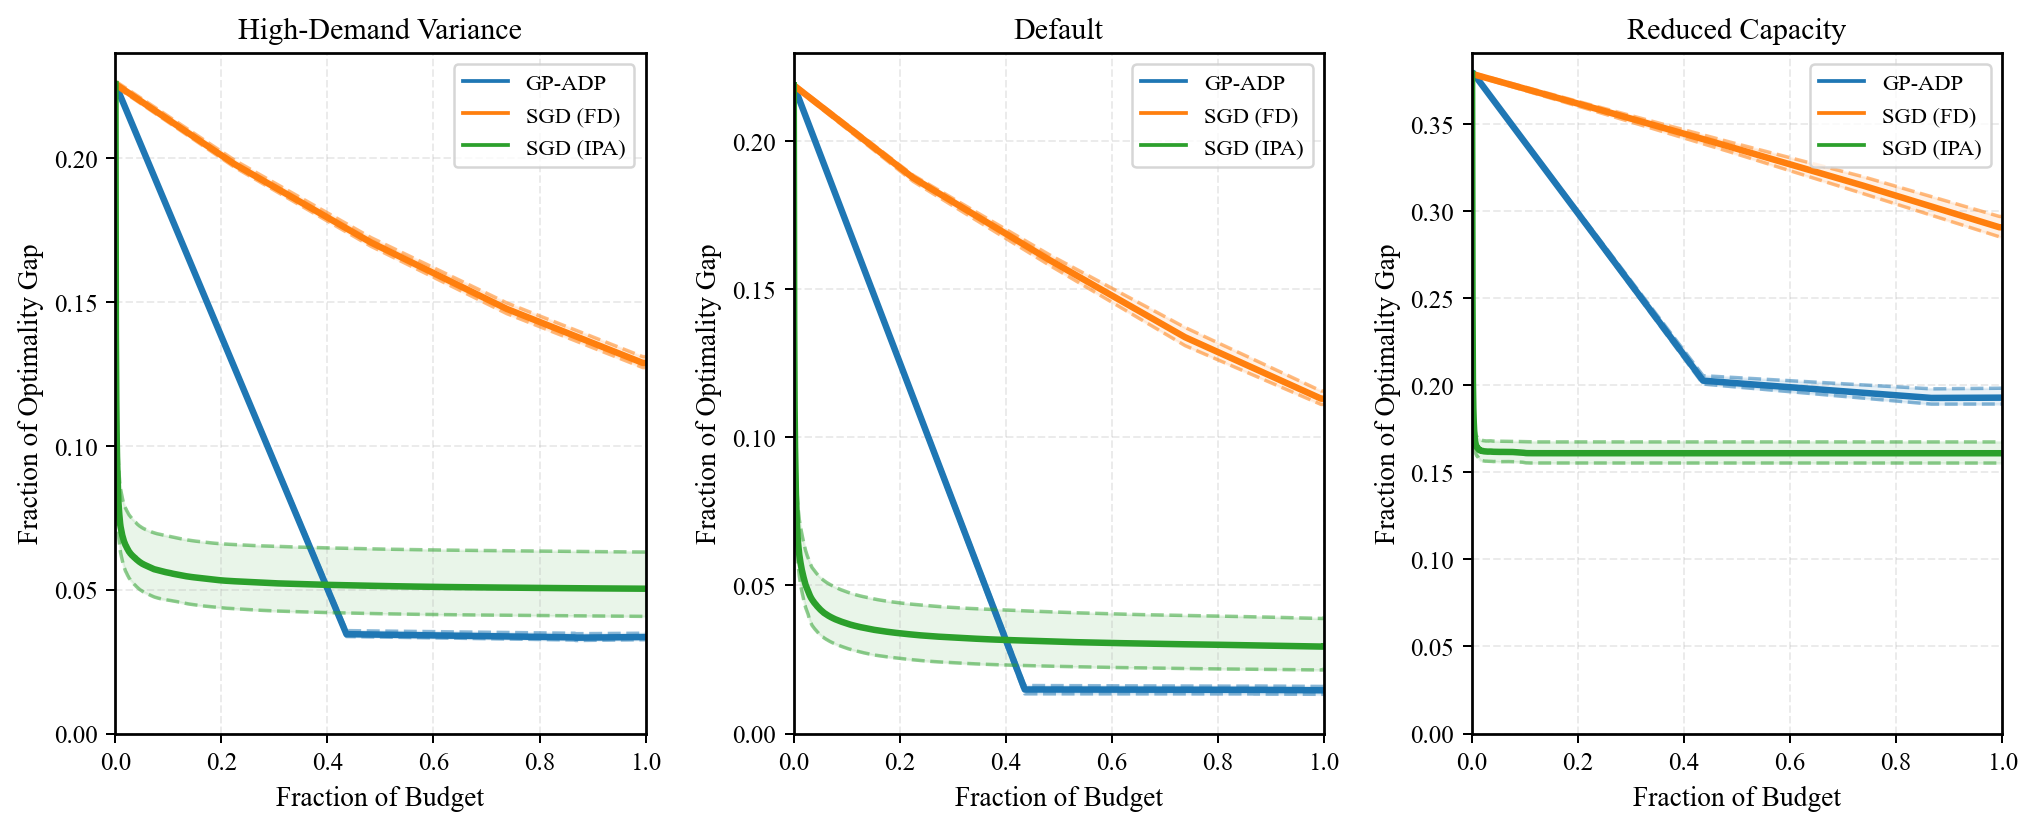

In [8]:
import matplotlib.pyplot as plt
from simopt.plots.optimality_gap import plot_optimality_gap_curves
from simopt.experiment_base import PlotType

def _variant_name(experiment) -> str:
    path_text = str(getattr(experiment, "file_name_path", "")).lower()
    if "reduced_capacity" in path_text:
        return "Reduced Capacity"
    if "increased_demand_variance" in path_text:
        return "High-Demand Variance"
    if "default_fixed_factors" in path_text:
        return "Default"
    return "Van Ryzin"

# --- Experiment 1: Optimality gap curves ---
# Group all Experiment 1 ProblemSolver objects by variant name.
exp1_by_variant: dict[str, list] = {}
for solver_experiments in wsc2026_exp_1.experiments:
    for exp in solver_experiments:
        variant = _variant_name(exp)
        if variant not in exp1_by_variant:
            exp1_by_variant[variant] = []

        # Exclude baseline DAVN and ADP (SGD) variants from this plot.
        solver_name = exp.solver.name
        if solver_name in {"DAVN", "ADP_ASTROMoRF", "ADP_SGD", "ADP (SGD)"}:
            continue

        if solver_name in {"ADP (SGD-IPA)", "ADP_(SGD-IPA)"}:
            exp.solver.name = "GP-ADP"
        exp1_by_variant[variant].append(exp)

print("Experiment 1 - variants found:", list(exp1_by_variant.keys()))
for v, exps in exp1_by_variant.items():
    print(f"  {v}: {[e.solver.name for e in exps]}")

with plt.rc_context(PAPER_PLOT_STYLE):
    _print_path_and_display(
        plot_optimality_gap_curves(
            experiments_by_variant=exp1_by_variant,
            plot_type=PlotType.MEAN,
            legend_loc="upper right",
            plot_conf_ints=True,
        ),
        export_pdf=True,
        legend_ncol=2,
    )

In [ ]:
# Get data from the CSV files. First load them as pandas dataframes, then print summary statistics per solver.
import ast
from scipy import stats
import pandas as pd

experiment_1_csv_path = Path("/Users/benjaminrees/Desktop/WSC2026_experiments/3_4_25/WSC2026_experiment1/csv_files")
path_1 = str(experiment_1_csv_path.parent)
pickles = [f for f in os.listdir(path_1) if f.endswith('.pickle') and 'ProblemsSolvers' not in f]

csv_files = [f for f in os.listdir(experiment_1_csv_path) if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files")

# Open each csv file and group rows by solver.
experiment_dictionaries = {}
for csv_file in csv_files:
    df = pd.read_csv(experiment_1_csv_path / csv_file)
    for _, row in df.iterrows():
        solver_name = row['solver']
        if solver_name not in experiment_dictionaries:
            experiment_dictionaries[solver_name] = []
        experiment_dictionaries[solver_name].append(row.to_dict())

print(f"Created experiment dictionaries for {len(experiment_dictionaries)} solvers")

def _mean_ci(values, confidence: float = 0.95) -> tuple[float, float]:
    samples = np.asarray(values, dtype=float)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        return np.nan, np.nan
    mean_value = float(samples.mean())
    if samples.size == 1:
        return mean_value, 0.0
    half_width = float(stats.t.ppf((1.0 + confidence) / 2.0, samples.size - 1) * stats.sem(samples))
    return mean_value, half_width

def _format_mean_ci(values, precision: int = 4, confidence: float = 0.95) -> str:
    mean_value, half_width = _mean_ci(values, confidence=confidence)
    return f"{mean_value:.{precision}f} ± {half_width:.{precision}f}"

# Reload the original solver pickles so the CI calculations use the raw replication data,
# not the post-normalized in-memory copies that may have had timings overwritten.
raw_experiments = [read_experiment_results(os.path.join(path_1, pkl)) for pkl in pickles]
experiment_lookup = {
    (experiment.solver.name, experiment.problem.name): experiment
    for experiment in raw_experiments
}

for solver_name, experiments in experiment_dictionaries.items():
    print(f"Solver: {solver_name}")
    data = experiments[0]
    problem_name = data['problem']
    load_factor_values = ast.literal_eval(data['load_factor']) if isinstance(data['load_factor'], str) else data['load_factor']
    demand_proxy_mean = data['demand_proxy_mean']
    best_solution_for_load_factor = data['best_solution_for_load_factor']

    matching_experiment = (
        experiment_lookup.get((data['solver_name'], problem_name))
        or experiment_lookup.get((data['solver'], problem_name))
    )

    if matching_experiment is not None and getattr(matching_experiment, 'all_est_objectives', None):
        final_objectives = [float(est[-1]) for est in matching_experiment.all_est_objectives if len(est) > 0]
    else:
        final_objectives = [data['mean_final_objective']]

    if matching_experiment is not None and getattr(matching_experiment, 'timings', None):
        runtime_seconds = [float(timing) for timing in matching_experiment.timings]
    else:
        runtime_seconds = [data['runtime_mean_seconds']]

    raw_iterations = getattr(matching_experiment, 'all_iterations', None) if matching_experiment is not None else None
    iterations = []
    if isinstance(raw_iterations, list):
        for iteration_list in raw_iterations:
            arr = np.asarray(iteration_list, dtype=float).reshape(-1)
            if arr.size > 0 and np.isfinite(arr[-1]):
                iterations.append(float(arr[-1]))
    if not iterations:
        iterations = [data['iterations_mean']]

    print(f"Mean Load Factor: {_format_mean_ci(load_factor_values)}")
    print(f"Mean Iterations: {_format_mean_ci(iterations)}")
    print(f"Mean Final Objective: {_format_mean_ci(final_objectives)}")
    print(f"Mean Runtime (seconds): {_format_mean_ci(runtime_seconds)}")
    print(f"Mean Demand Proxy: {demand_proxy_mean:.4f} (fixed from the problem data)")
    print(f"Best Solution for Load Factor: {best_solution_for_load_factor}")
    print("\n")

In [ ]:
# Get data from the CSV files. First load them as pandas dataframes, then print summary statistics per solver.
import ast
from scipy import stats
import pandas as pd

experiment_1_csv_path = Path("/Users/benjaminrees/Desktop/WSC2026_experiments/3_4_25/WSC2026_experiment1/csv_files")
path_1 = str(experiment_1_csv_path.parent)
pickles = [f for f in os.listdir(path_1) if f.endswith('.pickle') and 'ProblemsSolvers' not in f]

csv_files = [f for f in os.listdir(experiment_1_csv_path) if f.endswith('.csv')]

print(f"Found {len(csv_files)} CSV files")

# Open each csv file and group rows by solver.
experiment_dictionaries = {}
for csv_file in csv_files:
    df = pd.read_csv(experiment_1_csv_path / csv_file)
    for _, row in df.iterrows():
        solver_name = row['solver']
        if solver_name not in experiment_dictionaries:
            experiment_dictionaries[solver_name] = []
        experiment_dictionaries[solver_name].append(row.to_dict())

print(f"Created experiment dictionaries for {len(experiment_dictionaries)} solvers")

def _mean_ci(values, confidence: float = 0.95) -> tuple[float, float]:
    samples = np.asarray(values, dtype=float)
    samples = samples[np.isfinite(samples)]
    if samples.size == 0:
        return np.nan, np.nan
    mean_value = float(samples.mean())
    if samples.size == 1:
        return mean_value, 0.0
    half_width = float(stats.t.ppf((1.0 + confidence) / 2.0, samples.size - 1) * stats.sem(samples))
    return mean_value, half_width

def _format_mean_ci(values, precision: int = 4, confidence: float = 0.95) -> str:
    mean_value, half_width = _mean_ci(values, confidence=confidence)
    return f"{mean_value:.{precision}f} ± {half_width:.{precision}f}"

# Reload the original solver pickles so the CI calculations use the raw replication data,
# not the post-normalized in-memory copies that may have had timings overwritten.
raw_experiments = [read_experiment_results(os.path.join(path_1, pkl)) for pkl in pickles]
experiment_lookup = {
    (experiment.solver.name, experiment.problem.name): experiment
    for experiment in raw_experiments
}

for solver_name, experiments in experiment_dictionaries.items():
    print(f"Solver: {solver_name}")
    data = experiments[0]
    problem_name = data['problem']
    load_factor_values = ast.literal_eval(data['load_factor']) if isinstance(data['load_factor'], str) else data['load_factor']
    demand_proxy_mean = data['demand_proxy_mean']
    best_solution_for_load_factor = data['best_solution_for_load_factor']

    matching_experiment = (
        experiment_lookup.get((data['solver_name'], problem_name))
        or experiment_lookup.get((data['solver'], problem_name))
    )

    if matching_experiment is not None and getattr(matching_experiment, 'all_est_objectives', None):
        final_objectives = [float(est[-1]) for est in matching_experiment.all_est_objectives if len(est) > 0]
    else:
        final_objectives = [data['mean_final_objective']]

    if matching_experiment is not None and getattr(matching_experiment, 'timings', None):
        runtime_seconds = [float(timing) for timing in matching_experiment.timings]
    else:
        runtime_seconds = [data['runtime_mean_seconds']]

    raw_iterations = getattr(matching_experiment, 'all_iterations', None) if matching_experiment is not None else None
    iterations = []
    if isinstance(raw_iterations, list):
        for iteration_list in raw_iterations:
            arr = np.asarray(iteration_list, dtype=float).reshape(-1)
            if arr.size > 0 and np.isfinite(arr[-1]):
                iterations.append(float(arr[-1]))
    if not iterations:
        iterations = [data['iterations_mean']]

    print(f"Mean Load Factor: {_format_mean_ci(load_factor_values)}")
    print(f"Mean Iterations: {_format_mean_ci(iterations)}")
    print(f"Mean Final Objective: {_format_mean_ci(final_objectives)}")
    print(f"Mean Runtime (seconds): {_format_mean_ci(runtime_seconds)}")
    print(f"Mean Demand Proxy: {demand_proxy_mean:.4f} (fixed from the problem data)")
    print(f"Best Solution for Load Factor: {best_solution_for_load_factor}")
    print("\n")

In [9]:
import pandas as pd
from scipy import stats as sp_stats
from mrg32k3a.mrg32k3a import MRG32k3a


def _to_stage_decision(decision, problem):
    if decision is None:
        return None
    arr = np.asarray(decision, dtype=float).reshape(-1)
    if arr.size == 0 or not np.all(np.isfinite(arr)):
        return None

    stage_dim = getattr(problem, "dim", arr.size)
    n_stages = int(getattr(getattr(problem, "model", None), "n_stages", 1))
    if isinstance(stage_dim, (int, np.integer)) and stage_dim > 0:
        if n_stages > 1 and arr.size >= stage_dim * n_stages:
            return tuple(float(v) for v in arr[:stage_dim])
        if arr.size >= stage_dim:
            return tuple(float(v) for v in arr[:stage_dim])

    return tuple(float(v) for v in arr)


def _best_solver_protection_levels(experiment):
    all_xs = getattr(experiment, "all_recommended_xs", None)
    if not all_xs:
        return getattr(experiment, "xstar", None)

    all_fn = getattr(experiment, "all_fn_estimates", None)
    if not all_fn:
        all_fn = getattr(experiment, "all_est_objectives", None)

    minmax = getattr(experiment.problem, "minmax", (1,))
    if isinstance(minmax, (tuple, list, np.ndarray)):
        sense = int(minmax[0])
    else:
        sense = int(minmax)

    if all_fn:
        best_x = None
        best_val = None

        for mrep_idx, fn_seq in enumerate(all_fn):
            if fn_seq is None:
                continue
            fn_arr = np.asarray(fn_seq, dtype=float).reshape(-1)
            if fn_arr.size == 0 or not np.isfinite(fn_arr[-1]):
                continue
            if mrep_idx >= len(all_xs) or not all_xs[mrep_idx]:
                continue

            candidate_x = _to_stage_decision(all_xs[mrep_idx][-1], experiment.problem)
            if candidate_x is None:
                continue

            candidate_val = float(fn_arr[-1])
            if best_val is None or sense * candidate_val > sense * best_val:
                best_val = candidate_val
                best_x = candidate_x

        if best_x is not None:
            return best_x

    for xs_seq in all_xs:
        if xs_seq:
            candidate_x = _to_stage_decision(xs_seq[-1], experiment.problem)
            if candidate_x is not None:
                return candidate_x

    return getattr(experiment, "xstar", None)


def _estimate_optimal_load_factor_mean(problem, optimal_decision, n_reps: int = 100) -> float:
    model = getattr(problem, "model", None)
    if model is None:
        return np.nan
    if not hasattr(model, "factors") or "capacity" not in model.factors:
        return np.nan
    if not all(hasattr(model, attr) for attr in ("before_replication", "get_initial_state", "replicate_stage")):
        return np.nan
    if n_reps <= 0:
        return np.nan

    decision_stage = _to_stage_decision(optimal_decision, problem)
    if decision_stage is None:
        return np.nan

    capacity = np.asarray(model.factors["capacity"], dtype=float).reshape(-1)
    capacity = np.where(capacity < 0.0, 0.0, capacity)
    if capacity.size == 0:
        return np.nan

    total_capacity = float(np.sum(capacity))
    if not np.isfinite(total_capacity) or total_capacity <= 0.0:
        return np.nan

    n_stages = int(getattr(model, "n_stages", 1))
    n_rngs = int(getattr(model, "n_rngs", 0))
    if n_rngs <= 0:
        return np.nan

    remaining_fraction_sum = np.zeros_like(capacity, dtype=float)
    valid_reps = 0

    for rep_idx in range(int(n_reps)):
        rng_list = [
            MRG32k3a(s_ss_sss_index=[21_000 + rep_idx, rng_idx, 0])
            for rng_idx in range(n_rngs)
        ]

        model.before_replication(rng_list)
        state = model.get_initial_state()

        for stage in range(n_stages):
            _, state = model.replicate_stage(state, decision_stage, stage, rng_list)

        if not isinstance(state, dict) or "remaining_capacity" not in state:
            continue

        remaining = np.asarray(state["remaining_capacity"], dtype=float).reshape(-1)
        if remaining.size != capacity.size:
            continue

        remaining = np.clip(remaining, 0.0, capacity)
        remaining_fraction_sum += (remaining / total_capacity)
        valid_reps += 1

    if valid_reps == 0:
        return np.nan

    mean_remaining_fraction_per_leg = remaining_fraction_sum / float(valid_reps)
    return float(np.nanmean(mean_remaining_fraction_per_leg))


def _summary_rows(experiments_dict, experiment_label, n_opt_load_reps: int = 100):
    """Build summary rows from a variant->list[ProblemSolver] dict."""
    rows = []
    load_factor_cache: dict[tuple[str, str, str], float] = {}

    for variant, exps in experiments_dict.items():
        for exp in exps:
            solver_name = exp.solver.name
            problem_name = exp.problem.name
            opt_val = getattr(exp.problem, "optimal_value", None)

            # Final objectives across macroreps
            final_objs = []
            if hasattr(exp, "all_est_objectives") and exp.all_est_objectives:
                for seq in exp.all_est_objectives:
                    if seq is None:
                        continue
                    seq_arr = np.asarray(seq).reshape(-1)
                    if seq_arr.size == 0:
                        continue
                    final_objs.append(float(seq_arr[-1]))

            arr = np.array(final_objs, dtype=float)
            arr = arr[np.isfinite(arr)]
            obj_mean = float(arr.mean()) if arr.size > 0 else np.nan
            obj_std = float(arr.std(ddof=1)) if arr.size > 1 else np.nan
            if arr.size > 1:
                ci_hw = float(sp_stats.t.ppf(0.975, arr.size - 1) * sp_stats.sem(arr))
            else:
                ci_hw = np.nan

            gap_pct = np.nan
            if opt_val is not None and np.isfinite(opt_val) and opt_val > 0 and np.isfinite(obj_mean):
                gap_pct = 100.0 * (opt_val - abs(obj_mean)) / opt_val

            # Iterations: count per macrorep for this ProblemSolver, then average.
            iter_counts = []
            all_iterations = getattr(exp, "all_iterations", None)
            if all_iterations:
                for seq in all_iterations:
                    if seq is None:
                        continue
                    seq_arr = np.asarray(seq).reshape(-1)
                    if seq_arr.size == 0:
                        continue
                    iter_counts.append(float(seq_arr.size))
            iter_mean = float(np.mean(iter_counts)) if len(iter_counts) > 0 else np.nan

            # Runtime
            timings_arr = np.asarray(getattr(exp, "timings", []), dtype=float).reshape(-1)
            timings_arr = timings_arr[np.isfinite(timings_arr)]
            runtime_mean = float(np.mean(timings_arr)) if timings_arr.size > 0 else np.nan

            # Use each solver's own best protection levels for this variant/problem.
            cache_key = (variant, problem_name, solver_name)
            if cache_key not in load_factor_cache:
                solver_decision = _best_solver_protection_levels(exp)
                if solver_decision is None or np.asarray(solver_decision).reshape(-1).size == 0:
                    solver_decision = getattr(exp, "xstar", None)
                if solver_decision is None or np.asarray(solver_decision).reshape(-1).size == 0:
                    solver_decision = getattr(exp.problem, "optimal_solution", None)

                load_factor_cache[cache_key] = _estimate_optimal_load_factor_mean(
                    exp.problem,
                    solver_decision,
                    n_reps=n_opt_load_reps,
                )

            optimal_load_factor_mean = load_factor_cache[cache_key]
            optimal_capacity_utilization_pct = (
                100.0 * (1.0 - optimal_load_factor_mean) if np.isfinite(optimal_load_factor_mean) else np.nan
            )

            rows.append({
                "experiment": experiment_label,
                "variant": variant,
                "solver": solver_name,
                "problem": problem_name,
                "optimal_value_dlp": opt_val,
                "n_macroreps": exp.n_macroreps,
                "final_obj_mean": obj_mean,
                "final_obj_std": obj_std,
                "final_obj_ci_95": ci_hw,
                "optimality_gap_pct": gap_pct,
                "iterations_mean": iter_mean,
                "runtime_mean_s": runtime_mean,
                "optimal_solution_load_factor_mean": optimal_load_factor_mean,
                "optimal_solution_capacity_utilization_pct": optimal_capacity_utilization_pct,
            })
    return rows


def _variant_name_for_summary(experiment) -> str:
    path_text = str(getattr(experiment, "file_name_path", "")).lower()
    if "reduced_capacity" in path_text:
        return "Reduced Capacity"
    if "increased_demand_variance" in path_text:
        return "High-Demand Variance"
    if "default_fixed_factors" in path_text:
        return "Van Ryzin"
    return "Van Ryzin"


# Rebuild variant groups from the original Experiment 1 objects so no solver is dropped.
exp1_by_variant_all: dict[str, list] = {}
for solver_experiments in wsc2026_exp_1.experiments:
    for exp in solver_experiments:
        variant = _variant_name_for_summary(exp)
        if variant not in exp1_by_variant_all:
            exp1_by_variant_all[variant] = []
        exp1_by_variant_all[variant].append(exp)

print("Experiment 1 (all solvers) — variants found:", list(exp1_by_variant_all.keys()))
for v, exps in exp1_by_variant_all.items():
    print(f"  {v}: {[e.solver.name for e in exps]}")

all_rows = _summary_rows(exp1_by_variant_all, "Experiment 1", n_opt_load_reps=100)
# all_rows += _summary_rows(exp2_by_variant, "Experiment 2", n_opt_load_reps=100)

summary_df = pd.DataFrame(all_rows)
if not summary_df.empty and "solver" in summary_df.columns:
    solver_order = pd.Index(summary_df["solver"]).dropna().unique().tolist()
    summary_df["solver"] = pd.Categorical(
        summary_df["solver"],
        categories=solver_order,
        ordered=True,
    )
    summary_df = summary_df.sort_values(
        by=["solver", "variant", "problem"],
        kind="stable",
    ).reset_index(drop=True)
    summary_df["solver"] = summary_df["solver"].astype(str)
summary_csv_path = experiment_dir / "wsc2026_summary_statistics.csv"
summary_df.to_csv(summary_csv_path, index=False)
print(f"Summary CSV saved to: {summary_csv_path}")
display(summary_df)

Experiment 1 (all solvers) — variants found: ['High-Demand Variance', 'Van Ryzin', 'Reduced Capacity']
  High-Demand Variance: ['GP-ADP', 'ADP_ASTROMoRF', 'SGD (FD)', 'DAVN', 'SGD (IPA)', 'ADP (SGD)']
  Van Ryzin: ['GP-ADP', 'ADP_ASTROMoRF', 'SGD (FD)', 'DAVN', 'SGD (IPA)', 'ADP (SGD)']
  Reduced Capacity: ['GP-ADP', 'ADP_ASTROMoRF', 'SGD (FD)', 'DAVN', 'SGD (IPA)', 'ADP (SGD)']
Summary CSV saved to: /Users/benjaminrees/Desktop/WSC2026_experiments/wsc2026_summary_statistics.csv


,experiment,variant,solver,problem,optimal_value_dlp,n_macroreps,final_obj_mean,final_obj_std,final_obj_ci_95,optimality_gap_pct,iterations_mean,runtime_mean_s,optimal_solution_load_factor_mean,optimal_solution_capacity_utilization_pct
0,Experiment 1,High-Demand Variance,GP-ADP,VANRYZIN-2,177078.0,20,160306.988282,533.822263,249.836509,9.470974,118.0,268.570068,0.044315,95.568514
1,Experiment 1,Reduced Capacity,GP-ADP,VANRYZIN-2,153950.0,20,133860.303535,1713.715398,802.043495,13.049494,118.0,219.694850,0.054218,94.578223
2,Experiment 1,Van Ryzin,GP-ADP,VANRYZIN-2,177078.0,20,163929.166784,587.265820,274.848864,7.425447,118.0,265.661580,0.043513,95.648720
3,Experiment 1,High-Demand Variance,ADP_ASTROMoRF,VANRYZIN-2,177078.0,20,159143.370922,666.476924,311.920802,10.128096,7.4,476.788234,0.041978,95.802177
4,Experiment 1,Reduced Capacity,ADP_ASTROMoRF,VANRYZIN-2,153950.0,20,126482.289424,1069.379117,500.484832,17.841969,7.3,428.997868,0.029635,97.036534
5,Experiment 1,Van Ryzin,ADP_ASTROMoRF,VANRYZIN-2,177078.0,20,162684.564408,490.888773,229.743018,8.128303,6.6,373.984710,0.041167,95.883271
6,Experiment 1,High-Demand Variance,SGD (FD),VANRYZIN-2,177078.0,20,144502.233951,768.632165,359.730926,18.396281,5.0,3.332244,0.042151,95.784876
7,Experiment 1,Reduced Capacity,SGD (FD),VANRYZIN-2,153950.0,20,117621.650942,2100.798291,983.203865,23.597499,5.0,3.359020,0.030188,96.981207
8,Experiment 1,Van Ryzin,SGD (FD),VANRYZIN-2,177078.0,20,147541.918872,1014.517748,474.808921,16.679701,5.0,3.703154,0.041307,95.869298
9,Experiment 1,High-Demand Variance,DAVN,VANRYZIN-2,177078.0,20,140637.378362,371.368038,173.805592,20.578853,1.0,0.552098,0.020775,97.922515


## Experiment 2: Analysis of ADP solver under different SO Solvers

In this experiment, we obtain the ADP solver under different SO Solvers and plot the performance as a comparison

In [ ]:
path_2 = "/Users/benjaminrees/Desktop/WSC2026_experiments/3_4_25/WSC2026_experiment2/"

#find all the pickles in the directory that contain "POSTREPS" in the filename - get a list of their file paths
pickles = [f for f in os.listdir(path_2) if f.endswith('.pickle') and not "ProblemsSolvers" in f]



print(f"Found {len(pickles)} pickles")
[print(f) for f in pickles]

#now load. the pickle files as ProblemsSolvers objects

ps_list = []
experiments_2 = []
for pkl in pickles:
    #load in experiments but if the solver is RNDSR, skip it
    experiment = read_experiment_results(os.path.join(path_2, pkl))
    # if experiment.solver.name == "RANDOM SEARCH":
    #     print(f"Skipping RNDSR experiment: {pkl}")
    #     continue
    experiments_2.append(experiment) 

print(f"Loaded {len(experiments_2)} experiments")

#print the number of macroreps for each experiment
for exp in experiments_2:
    print(f"Experiment: {exp.solver.name} on {exp.problem.name} has {exp.n_macroreps} macroreps")

In [ ]:
#Create an instance of ProblemsSolvers that contains all the experiments

#first need to make experiments a list of list of ProblemSolver objects where each inner list has the same solver 

experiments_sorted = {}
for exp in experiments_2:
    key = exp.solver.name
    if key not in experiments_sorted:
        experiments_sorted[key] = []
    experiments_sorted[key].append(exp)

# pretty print each solver and problem pair in the experiments_sorted
for solver_name, exps in experiments_sorted.items():
    for exp in exps:
        print(f"Solver: {solver_name}, Problem: {exp.problem.name}")
    print("\n")

#now turn experiments_sorted into a list of lists where each value of the dict is a sublist 
ps_list = list(experiments_sorted.values())

file_name_path = experiment_dir / "wsc2026_exp_2.pickle"
wsc2026_exp_2 = ProblemsSolvers(experiments=ps_list, file_name_path=file_name_path)

print(f'WSC2026 Experiment 2 ProblemsSolvers has file path: {wsc2026_exp_2.file_name_path}')

In [ ]:
#get number of postreps from first experiment in the list
num_postreps_init_opt = experiments_2[0].n_postreps

# Configure logging so we see which pair is currently running
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
print("Logging set to INFO. You will see per-pair progress as they start/finish.")

print("Post-normalizing results.")

# Find an optimal solution x* for normalization.
wsc2026_exp_2.post_normalize_policy(n_postreps_init_opt=num_postreps_init_opt)

In [ ]:
# Produce basic plots.
import matplotlib.pyplot as plt
from IPython.display import Image, display

from simopt.experiment_base import PlotType, plot_solvability_profiles, plot_budget_history, plot_fn_estimates, plot_progress_curves

SAVE_PATH: Path | None = None 

print("Plotting results...")

ps_same_problem_dict = {}
# take the experiments of comparison_experiment and create a list of lists from ps_same_problem_list where each sublist contains all solvers for a given problem
experiments_flattened = [ps for solver_experiments in wsc2026_exp_2.experiments for ps in solver_experiments]
for exp in experiments_flattened:
    if exp.problem.name not in ps_same_problem_dict:
        ps_same_problem_dict[exp.problem.name] = []
    ps_same_problem_dict[exp.problem.name].append(exp)

#turn the items of ps_same_problem_dict into a list of lists
experiments_same_problem = []
for problem_name, ps_list in ps_same_problem_dict.items():
    experiments_same_problem.append(ps_list)


# wsc2026_exp_2.experiments is structured as experiments[solver_idx][problem_idx]
# To plot all solvers for each problem, we need to transpose the structure
n_solvers = len(wsc2026_exp_2.experiments)
n_problems = len(wsc2026_exp_2.experiments[0]) if n_solvers > 0 else 0

In [ ]:
SAVE_PATH = _print_path_and_display(
    plot_solvability_profiles(
        experiments=wsc2026_exp_2.experiments,
        plot_type=PlotType.CDF_SOLVABILITY,
        solve_tol=0.1,
        plot_title="Comparison of SO Solvers on the GP-ADP Reformulation",
        legend_loc="upper left",
        plot_conf_ints=True
    ),
    legend_outside=True,
 )

# Group by explicit variant name so default and high-demand-variance are not merged.
from collections import defaultdict

def _start_solution_signature(experiment) -> tuple[float, ...] | None:
    x0 = getattr(experiment, "x0", None)
    if x0 is None:
        return None
    x0_array = np.asarray(x0, dtype=float).reshape(-1)
    rounded = np.round(x0_array, 12)
    return tuple(float(v) for v in rounded)

def _variant_name(experiment) -> str:
    path_text = str(getattr(experiment, "file_name_path", "")).lower()
    if "reduced_capacity" in path_text:
        return "Reduced Capacity"
    if "increased_demand_variance" in path_text:
        return "High-Demand Variance"
    if "default_fixed_factors" in path_text:
        return "Van Ryzin"
    return "Van Ryzin"

# Keep the solver display order stable in each variant-level comparison.
target_solver_names = ["ADP_SGD", "ADP_ASTROMoRF", "ADP_NELDER-MEAD", "ADP_ASTRO-DF"]

experiments_flat = [
    exp
    for solver_experiments in wsc2026_exp_2.experiments
    for exp in solver_experiments
]

experiments_by_variant = defaultdict(list)
for exp in experiments_flat:
    key = (exp.problem.name, _variant_name(exp), _start_solution_signature(exp))
    experiments_by_variant[key].append(exp)

if not experiments_by_variant:
    print("No experiments were found for plotting.")

for (problem_name, variant_name, _), variant_experiments in experiments_by_variant.items():
    solver_index = {exp.solver.name: exp for exp in variant_experiments}
    comparison_experiments = [
        solver_index[solver_name]
        for solver_name in target_solver_names
        if solver_name in solver_index
    ]
    #Check if variant name is default factors

    if len(comparison_experiments) < 2:
        available = sorted(solver_index.keys())
        print(
            f"Skipping {variant_name} variant for {problem_name}; "
            f"need at least two solvers, found {available}."
        )
        continue
    
    for exp in comparison_experiments:
        exp_for_plot = copy.copy(exp)
        exp_for_plot.solver = copy.copy(exp.solver)
        exp_for_plot.solver.name = f"{exp.solver.name} ({variant_name})"

        if combined_ref_x0 is None:
            combined_ref_x0 = np.asarray(exp.x0).reshape(-1).copy()
        if combined_ref_xstar is None:
            combined_ref_xstar = np.asarray(exp.xstar).reshape(-1).copy()

        # Harmonize references on the copied objects only so combined plotting passes
        # the strict common x0/x* checks without mutating original experiment objects.
        exp_for_plot.x0 = tuple(np.asarray(combined_ref_x0).tolist())
        exp_for_plot.xstar = tuple(np.asarray(combined_ref_xstar).tolist())

        combined_progress_experiments.append(exp_for_plot)

    print(
        f"Plotting {problem_name} ({variant_name}) for "
        f"{[exp.solver.name for exp in comparison_experiments]}"
    )

    

    SAVE_PATH = _print_path_and_display(
        plot_progress_curves(
            experiments=comparison_experiments,
            plot_type=PlotType.MEAN,
            plot_title=f"SO Solvers on the GP-ADP Reformulation for {variant_name}",
            legend_loc="upper right",
            plot_conf_ints=True
        ),
        legend_outside=True,
    )

    _print_path_and_display(
        plot_fn_estimates(
            experiments=comparison_experiments,
            plot_type=PlotType.FN_ESTIMATES_MEAN,
            solver_set_name=f"Function Estimates for {problem_name} ({variant_name})",
            plot_title=f"SO Solvers on the GP-ADP Reformulation for {variant_name}",
            normalize=True,
            y_normalize=True,
            legend_loc="upper right",
        ),
        legend_outside=True,
    )

In [ ]:
import copy
import importlib
import matplotlib.pyplot as plt

import simopt.plots.optimality_gap as optimality_gap_plot
importlib.reload(optimality_gap_plot)
plot_optimality_gap_curves = optimality_gap_plot.plot_optimality_gap_curves

# --- Experiment 2: Optimality gap curves ---
def _display_solver_name(name: str) -> str:
    alias_map = {
        "ADP_SGD": "GP-ADP (SGD)",
        "ADP_ASTRO-DF": "GP-ADP (ASTRO-DF)",
        "ADP_ASTROMoRF": "GP-ADP (ASTROMoRF)",
        "ADP_NELDER-MEAD": "GP-ADP (NELDER-MEAD)",
        "ADP (SGD)": "GP-ADP (SGD)",
        "ADP (ASTRO-DF)": "GP-ADP (ASTRO-DF)",
        "ADP (ASTROMoRF)": "GP-ADP (ASTROMoRF)",
        "ADP (NELDER-MEAD)": "GP-ADP (NELDER-MEAD)",
    }
    if name in alias_map:
        return alias_map[name]
    if name.startswith("GP-ADP ("):
        return name
    if name.startswith("ADP ("):
        return name.replace("ADP (", "GP-ADP (", 1)
    return name

exp2_by_variant: dict[str, list] = {}
for solver_experiments in wsc2026_exp_2.experiments:
    for exp in solver_experiments:
        exp_for_plot = copy.copy(exp)
        exp_for_plot.solver = copy.copy(exp.solver)
        exp_for_plot.solver.name = _display_solver_name(exp.solver.name)

        variant = _variant_name(exp_for_plot)
        if variant not in exp2_by_variant:
            exp2_by_variant[variant] = []
        exp2_by_variant[variant].append(exp_for_plot)

print("Experiment 2 - variants found:", list(exp2_by_variant.keys()))
for variant_name, exps in exp2_by_variant.items():
    solver_names = sorted({e.solver.name for e in exps})
    has_astro_df = "GP-ADP (ASTRO-DF)" in solver_names
    print(f"  {variant_name}: {solver_names}")
    print(f"    GP-ADP (ASTRO-DF) present: {has_astro_df}")

with plt.rc_context(PAPER_PLOT_STYLE):
    _print_path_and_display(
        plot_optimality_gap_curves(
            experiments_by_variant=exp2_by_variant,
            plot_type=PlotType.MEAN,
            legend_loc="upper right",
            plot_conf_ints=True,
        ),
        export_pdf=True,
        legend_ncol=2,
    )